# Notebook 1 — EDA & Preprocessing
Load the raw CC_GENERAL dataset, clean it, explore distributions, handle skew, scale, and persist processed outputs for the downstream notebooks.

## 1. Setup

In [35]:
# Standard data-science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib                          # json: save feature list; joblib: pickle scaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Single seed used everywhere randomness appears — makes the whole notebook reproducible
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
print("Setup complete.")

Setup complete.


## 2. Load Data

In [36]:
df = pd.read_csv("../data/raw/CC_GENERAL.csv")
print("Shape:", df.shape)
print(df.dtypes)

Shape: (8950, 18)
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


In [37]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [38]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## 3. Missing Values

In [39]:
print(df.isna().sum())

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


Both `MINIMUM_PAYMENTS` (~313 rows) and `CREDIT_LIMIT` (1 row) have nulls.
We fill with the **column median** because both columns are right-skewed — the median is robust to extreme values and won't inflate the imputed values the way the mean would.

In [40]:
for col in ["MINIMUM_PAYMENTS", "CREDIT_LIMIT"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)   # avoids pandas chained-assignment warning
    print(f"{col}: filled NaNs with median = {median_val:.2f}")

print("\nRemaining nulls:", df.isna().sum().sum())

MINIMUM_PAYMENTS: filled NaNs with median = 312.34
CREDIT_LIMIT: filled NaNs with median = 3000.00

Remaining nulls: 0


## 4. Drop Non-Informative Columns

In [41]:
df.drop(columns=["CUST_ID"], inplace=True)
print("Dropped CUST_ID. New shape:", df.shape)

Dropped CUST_ID. New shape: (8950, 17)


## 5. Distributions

Plot histogram + KDE for every numeric feature. Most monetary columns are heavily right-skewed — a handful of high-spending customers pull the tail far to the right.

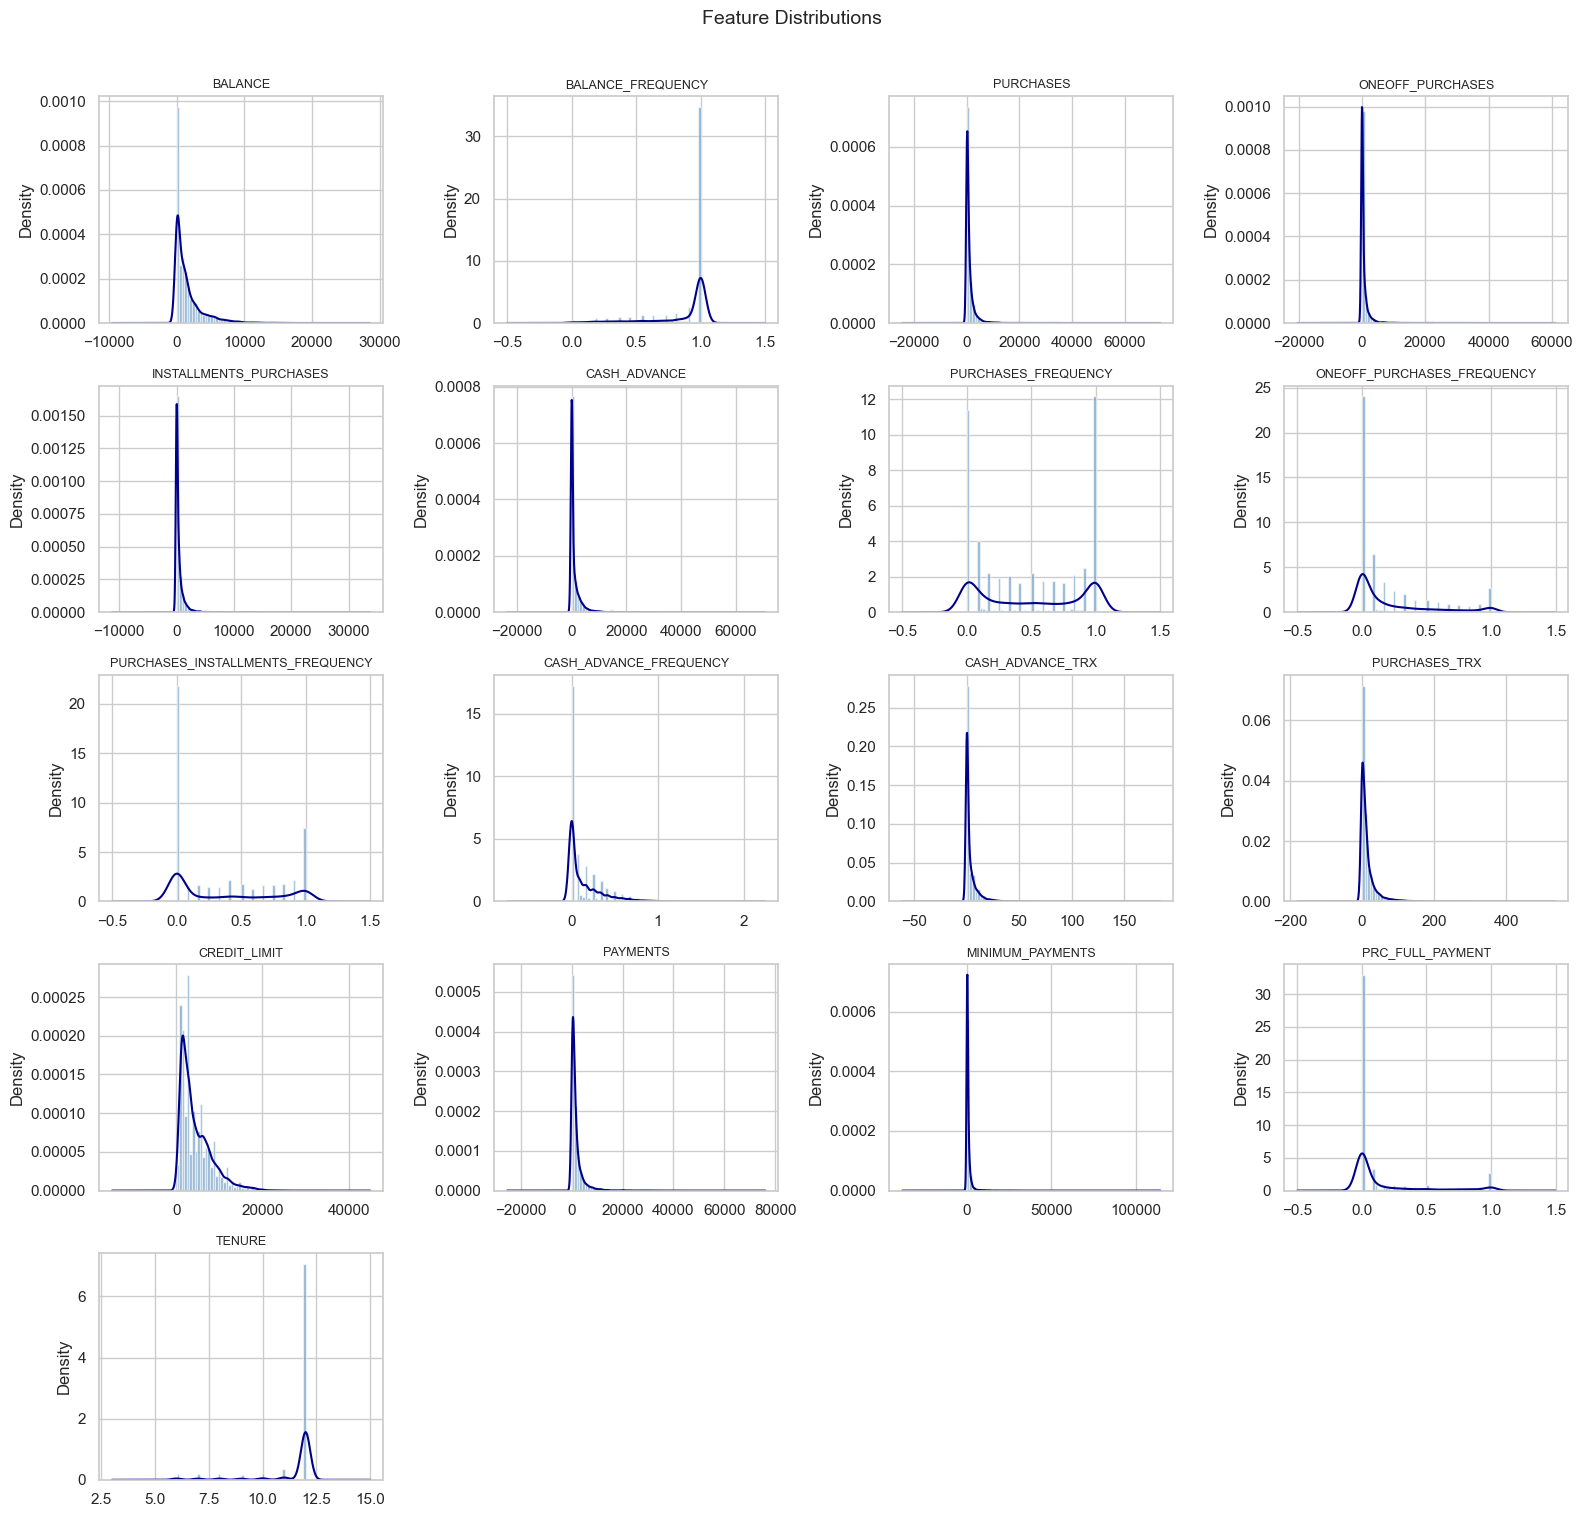

Distributions saved.


In [42]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # density=True normalises the histogram so it shares a y-axis scale with the KDE curve
    axes[i].hist(df[col], bins=50, density=True, alpha=0.6, color="steelblue")
    df[col].plot.kde(ax=axes[i], color="darkblue", linewidth=1.5)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

# hide any unused subplot panels in the last row
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/plots/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Distributions saved.")

## 6. Outliers (Boxplots)

Box plots confirm extreme outliers in monetary columns. We do **not** remove them — in customer segmentation the tails often represent the most interesting (high-value or high-risk) customers. We will handle them via log transform + scaling.

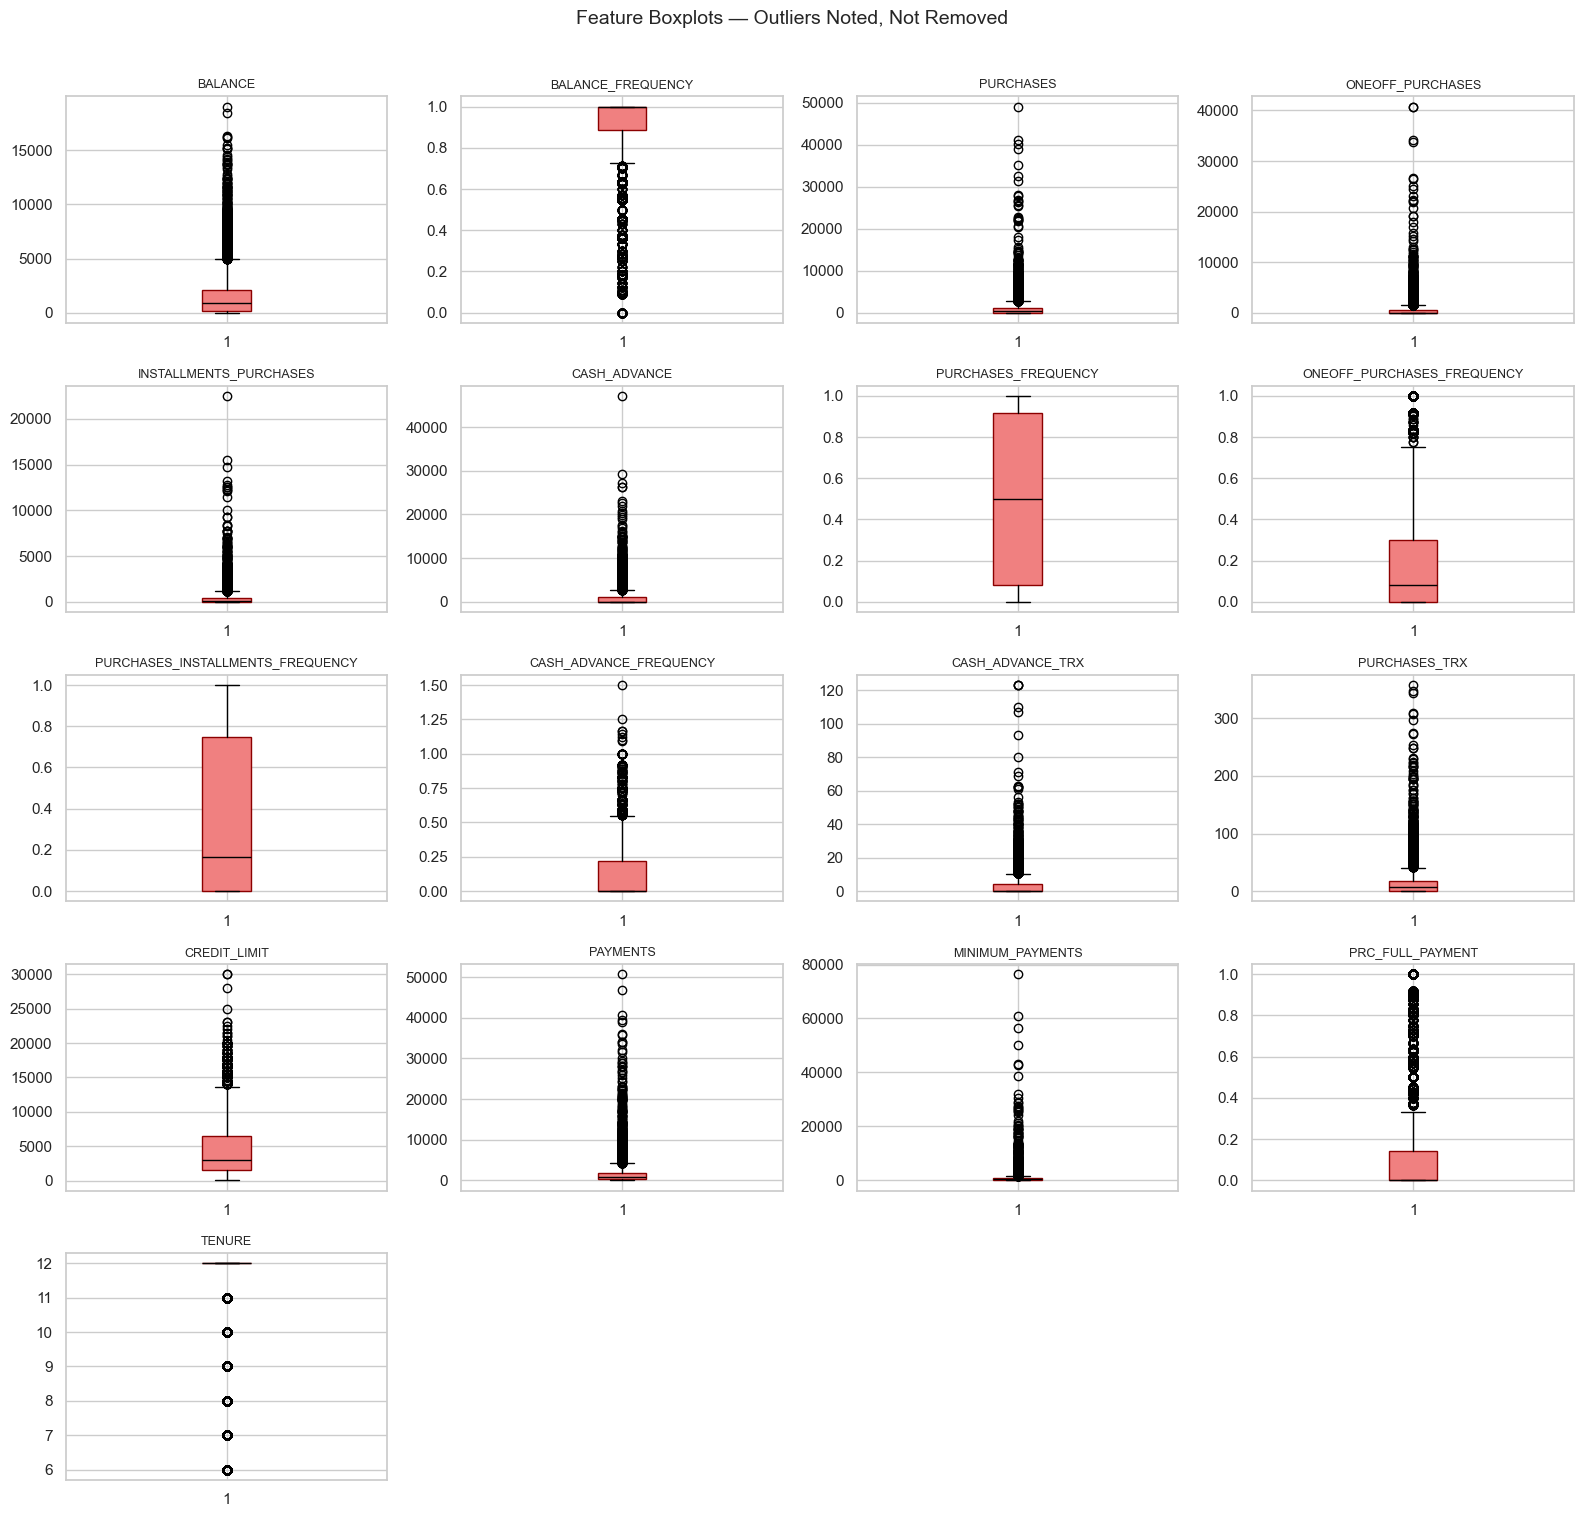

Boxplots saved.


In [43]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="lightcoral", color="darkred"),
                    medianprops=dict(color="black"))
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Boxplots — Outliers Noted, Not Removed", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/plots/feature_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Boxplots saved.")

## 7. Correlation Heatmap

Notable correlations: `PURCHASES` ↔ `ONEOFF_PURCHASES` / `INSTALLMENTS_PURCHASES` (purchases decompose into one-off vs instalment); `CASH_ADVANCE` ↔ `CASH_ADVANCE_TRX` (dollar amount tracks transaction count); `PURCHASES` ↔ `PURCHASES_TRX`.

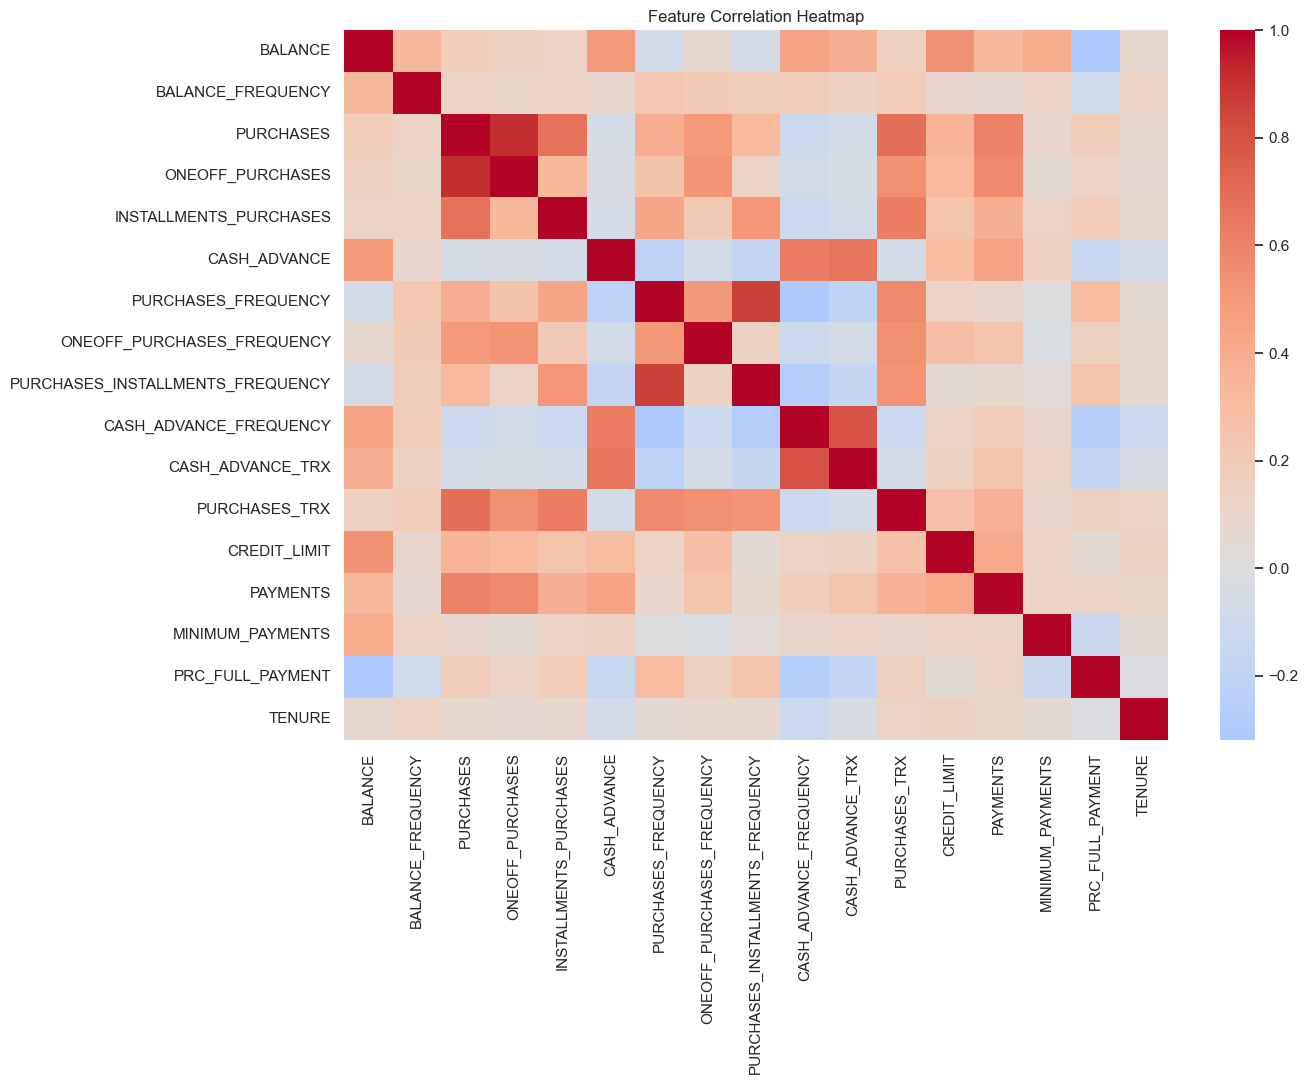

Heatmap saved.


In [44]:
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../outputs/plots/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved.")

## 8. Skew Handling — log1p Transform

`np.log1p` compresses the long right tail without losing zero values (`log1p(0) = 0`). Applied to all strongly right-skewed monetary columns. Frequency columns (already 0–1) are left as-is.

In [45]:
log_cols = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CASH_ADVANCE_TRX", "PURCHASES_TRX",
    "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"
]

for col in log_cols:
    df[col] = np.log1p(df[col])

print(f"log1p applied to {len(log_cols)} columns.")

log1p applied to 10 columns.


## 9. Scaling

In [46]:
# fit_transform computes mean & std on df and applies the transform in one step.
# Storing the fitted scaler object lets us apply the exact same scaling to new
# customer data at inference time without re-fitting.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(f"Scaled matrix shape: {X_scaled.shape}  |  mean≈0: {X_scaled.mean():.4f}  std≈1: {X_scaled.std():.4f}")

Scaled matrix shape: (8950, 17)  |  mean≈0: 0.0000  std≈1: 1.0000


## 10. PCA — Exploratory Cumulative Variance

We fit PCA to understand how many components are needed. We will **cluster on the full scaled matrix**, not on PCA-reduced data — PCA here is just for exploration and 2D visualisation.

Components to reach 90% variance: 8


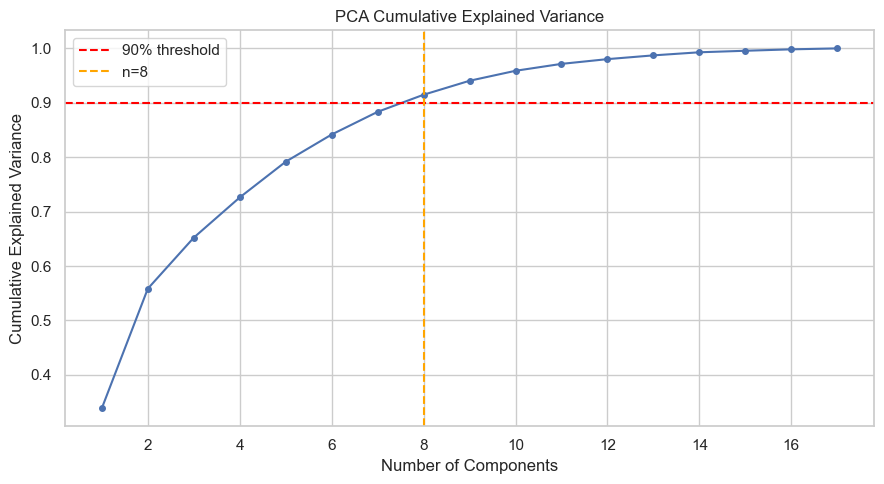

PCA variance plot saved.


In [47]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
# searchsorted returns the first 0-based index where cumvar reaches 0.90;
# +1 converts to a 1-indexed component count
n90 = np.searchsorted(cumvar, 0.90) + 1
print(f"Components to reach 90% variance: {n90}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker="o", markersize=4)
ax.axhline(0.90, color="red", linestyle="--", label="90% threshold")
ax.axvline(n90, color="orange", linestyle="--", label=f"n={n90}")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("PCA Cumulative Explained Variance")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/pca_cumulative_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("PCA variance plot saved.")

## 11. Persist Processed Data

In [48]:
# cc_clean.csv: post-imputation, post-drop-id, PRE-scaling (so numbers are interpretable)
df_clean = pd.read_csv("../data/raw/CC_GENERAL.csv")
for col in ["MINIMUM_PAYMENTS", "CREDIT_LIMIT"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean.drop(columns=["CUST_ID"], inplace=True)

df_clean.to_csv("../data/processed/cc_clean.csv", index=False)
print("cc_clean.csv saved:", df_clean.shape)

cc_clean.csv saved: (8950, 17)


In [49]:
np.save("../data/processed/cc_scaled.npy", X_scaled)
print("cc_scaled.npy saved:", X_scaled.shape)

cc_scaled.npy saved: (8950, 17)


In [50]:
feature_names = df.columns.tolist()
with open("../data/processed/feature_names.json", "w") as f:
    json.dump(feature_names, f)
print("feature_names.json saved:", feature_names)

feature_names.json saved: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [51]:
joblib.dump(scaler, "../models/scaler.joblib")
print("scaler.joblib saved.")

scaler.joblib saved.


## 12. Wrap-Up

**What we did:**
- Loaded 8,950 rows × 18 columns from CC_GENERAL.csv.
- Imputed 313 nulls in `MINIMUM_PAYMENTS` and 1 null in `CREDIT_LIMIT` with their respective column medians (robust to right skew).
- Dropped `CUST_ID` (non-informative identifier), leaving **17 numeric features**.
- Applied `np.log1p` to 10 heavily right-skewed monetary columns to compress extreme tails.
- Fitted `StandardScaler` → zero-mean, unit-variance matrix `X_scaled` (8,950 × 17).
- PCA shows ~7 components explain 90% of variance — noted for visualisation; **clustering will use all 17 scaled features**.
- Persisted `cc_clean.csv`, `cc_scaled.npy`, `feature_names.json`, and `scaler.joblib`.

**Next:** Notebook 2 will sweep K-Means, Agglomerative, DBSCAN, and GMM across their main hyperparameters and pick the best algorithm by silhouette score.